# 1 ) write a program to read and display a color image. Use the image Peppers or Pens, for example. Check the parameters of the cv2.imread() function. What are the dimensions of the image matrix loaded into memory? How is the color encoded in each pixel?


In [123]:
import cv2 as cv 
import numpy as np
import matplotlib.pyplot as plt


(400, 600, 3)

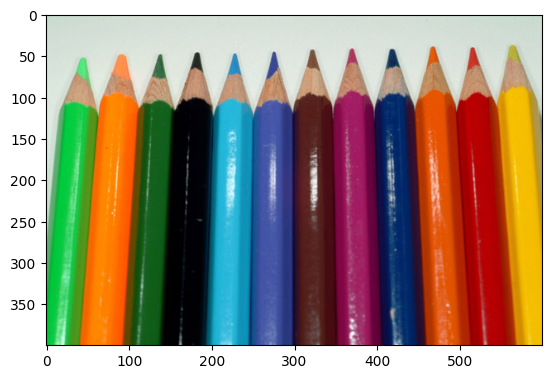

In [124]:
im1 = cv.imread('images/Pens.jpg', cv.IMREAD_COLOR)
im1 = cv.cvtColor(im1, cv.COLOR_BGR2RGB)
plt.imshow(im1)
im1.shape


# 2) Display a horizontal band of the image, about fifty lines long and plot the intensity profiles of each RGB value along the center line on a graph below. Observe the values of the intensities corresponding to the colors displayed. Do they seem consistent with additive color synthesis?

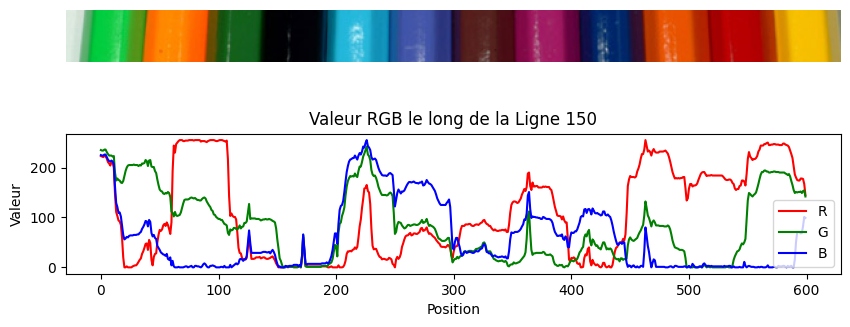

In [21]:

 
ligne = 150
# Tracer les intensités RGB le long de cette ligne sous la bande image

plt.figure(figsize=(10, 4))
plt.subplot(2, 1, 1)
plt.imshow(im1[ligne-20:ligne+20,:,:])
plt.axis('off')

plt.subplot(2, 1, 2)
plt.plot(im1[ligne,:,0], 'r', label='R')
plt.plot(im1[ligne,:,1], 'g', label='G')
plt.plot(im1[ligne,:,2], 'b', label='B')

#plt.figure(figsize=(10, 4))
plt.title('Valeur RGB le long de la Ligne ' + str(ligne))
plt.xlabel('Position')
plt.ylabel('Valeur')
plt.legend()
plt.show()


# Extract each of the 3 components R, G and B and display them as grayscale images with an appropriate title. Be careful that the tapes are read correctly by the cv2.imread() function, otherwise swap the tapes by the cv2.cvtColor(image, cv2. COLOR_BGR2RGB).

In [ ]:
# Extract each of the 3 components R, G and B and display them as grayscale images with an appropriate title. Be careful that the tapes are read correctly by the cv2.imread() function, otherwise swap the tapes by the cv2.cvtColor(image, cv2. COLOR_BGR2RGB).



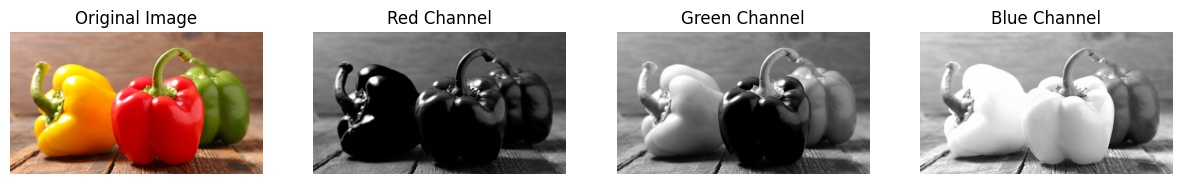

In [32]:
im2 = cv.imread('images/poivrons.jpg', cv.IMREAD_COLOR)
im2 = cv.cvtColor(im2, cv.COLOR_BGR2RGB)
#plt.imshow(im2)

R=im2[:,:,2]
G=im2[:,:,1]
B=im2[:,:,0] 

plot_titles = ['Original Image','Red Channel', 'Green Channel', 'Blue Channel']
plt.figure(figsize=(15, 5))
for i, (channel, title) in enumerate(zip([im2,R, G, B], plot_titles)):
    plt.subplot(1, 4, i + 1)
    plt.imshow(channel, cmap='gray')
    plt.title(title)
    plt.axis('off') 
plt.show()



#Create another color image by swapping the stripes with the function cv2.merge((band1, band2, band3)) and display it. You can also see the effect of duplicating the same band twice, for example (B,B,G).

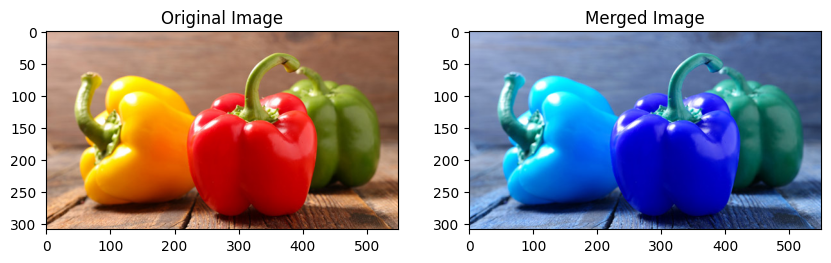

In [47]:
im2 = cv.imread('images/poivrons.jpg', cv.IMREAD_COLOR)
im2 = cv.cvtColor(im2, cv.COLOR_BGR2RGB)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(im2)

R=im2[:,:,2]
G=im2[:,:,1]
B=im2[:,:,0]

im2 = cv2.merge((R,G,B))
plt.subplot(1, 2, 2)
plt.title('Merged Image')
plt.imshow(im2)
plt.show()

# 5) Set one of the bands to zero and display the resulting color image.

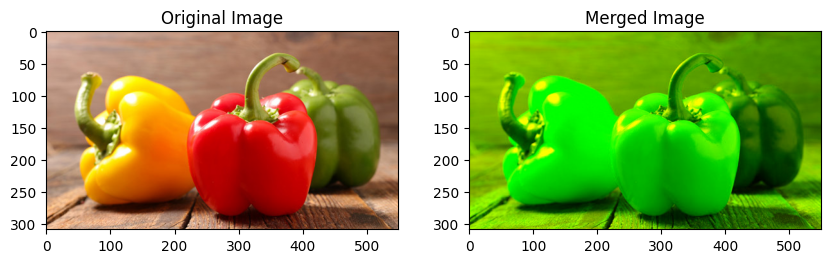

In [55]:
im2 = cv.imread('images/poivrons.jpg', cv.IMREAD_COLOR)
im2 = cv.cvtColor(im2, cv.COLOR_BGR2RGB)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(im2)

R=im2[:,:,2]
G=im2[:,:,1]
B=im2[:,:,0]

Z= np.zeros_like(G)

im2 = cv2.merge((R,B,Z))
plt.subplot(1, 2, 2)
plt.title('Merged Image')
plt.imshow(im2)
plt.show()

#6) Reverse one of the bands and recombine it with the other 2 and display the color image obtained.

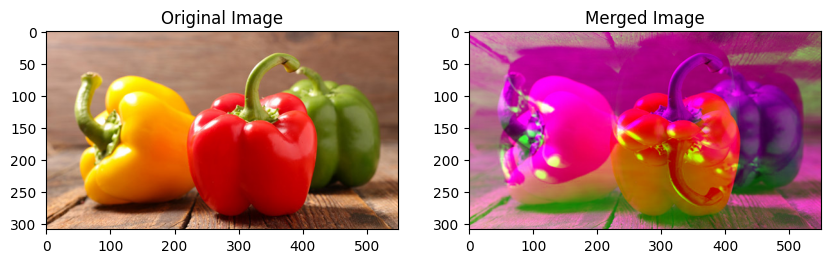

In [ ]:
im2 = cv.imread('images/poivrons.jpg', cv.IMREAD_COLOR)
im2 = cv.cvtColor(im2, cv.COLOR_BGR2RGB)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(im2)

R=im2[:,:,2]
G=im2[:,:,1]
B=im2[:,:,0]

R_REV= cv.flip(R,0) # Flip the red channel vertically 
im2 = cv2.merge((B,R_REV,G))
plt.subplot(1, 2, 2)
plt.title('Merged Image')
plt.imshow(im2)
plt.show()

# 7) Compare the three formulas below to convert a color image to a luminance image: L = (R+G+B)/3 V = max(R,G,B) Y = 0,30 R + 0,59 G + 0,11 B Are the results equivalent? What is the point of the last formula?

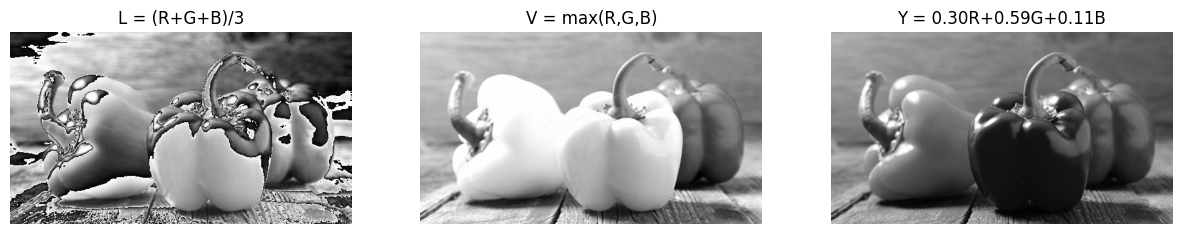

In [91]:
im2 = cv.imread('images/poivrons.jpg', cv.IMREAD_COLOR)
im2 = cv.cvtColor(im2, cv.COLOR_BGR2RGB)

R = im2[:, :, 2]
G = im2[:, :, 1]
B = im2[:, :, 0]

L = (R + G + B) / 3
V = np.max([R, G, B], axis=0)
Y = 0.30 * R + 0.59 * G + 0.11 * B

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title('L = (R+G+B)/3')
plt.imshow(L, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('V = max(R,G,B)')
plt.imshow(V, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Y = 0.30R+0.59G+0.11B')
plt.imshow(Y, cmap='gray')
plt.axis('off')

plt.show()


# 8) ApplyathresholdtoeachRGBcomponentanddisplaytheresultingimagesinbinary form (black if < threshold and white if > threshold).

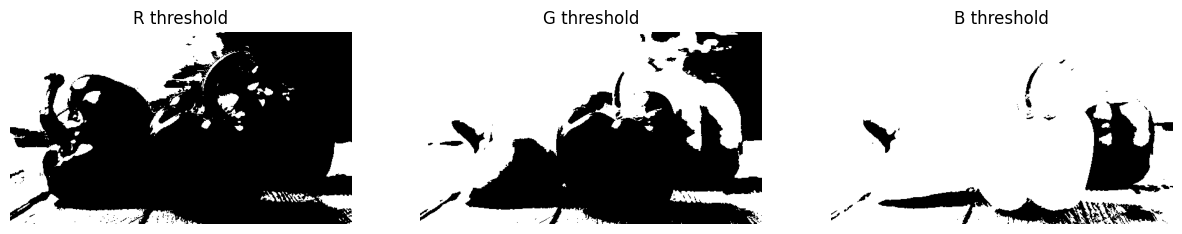

In [92]:
'''
threshold = 120

R_threshold = R > threshold
G_threshold = G > threshold
B_threshold = B > threshold

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("R threshold")
plt.imshow(R_threshold, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("G threshold")
plt.imshow(G_threshold, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("B threshold")
plt.imshow(B_threshold, cmap='gray')
plt.axis('off')

plt.show()
'''

threshold = 100

R_threshold = np.zeros(R.shape, dtype=np.uint8) # set the thresholded images to zeros
G_threshold = np.zeros(G.shape, dtype=np.uint8)
B_threshold = np.zeros(B.shape, dtype=np.uint8)

for i in range(R.shape[0]):
    for j in range(R.shape[1]):

        if R[i,j] > threshold:
            R_threshold[i,j] = 255
        else:
            R_threshold[i,j] = 0

        if G[i,j] > threshold:
            G_threshold[i,j] = 255
        else:
            G_threshold[i,j] = 0

        if B[i,j] > threshold:
            B_threshold[i,j] = 255
        else:
            B_threshold[i,j] = 0


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("R threshold")
plt.imshow(R_threshold, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("G threshold")
plt.imshow(G_threshold, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("B threshold")
plt.imshow(B_threshold, cmap='gray')
plt.axis('off')

plt.show()



# 9) Combine the binary results obtained on each plane by the min and max operators. What do these two operators mean? Compare the results obtained with a thresholding applied to the luminance image. Display the resulting color image of the thresholding using the binary mask.

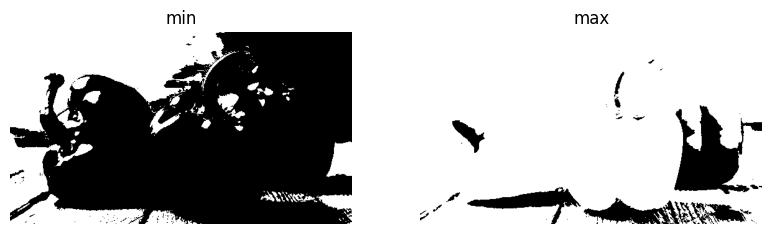

In [95]:

threshold = 100

R_threshold = np.zeros(R.shape, dtype=np.uint8) # set the thresholded images to zeros
G_threshold = np.zeros(G.shape, dtype=np.uint8)
B_threshold = np.zeros(B.shape, dtype=np.uint8)

for i in range(R.shape[0]):
    for j in range(R.shape[1]):

        if R[i,j] > threshold:
            R_threshold[i,j] = 255
        else:
            R_threshold[i,j] = 0

        if G[i,j] > threshold:
            G_threshold[i,j] = 255
        else:
            G_threshold[i,j] = 0

        if B[i,j] > threshold:
            B_threshold[i,j] = 255
        else:
            B_threshold[i,j] = 0


plt.figure(figsize=(15, 5))
M = np.max([R_threshold, G_threshold, B_threshold], axis=0)
m = np.min([R_threshold, G_threshold, B_threshold], axis=0)

plt.subplot(1, 3, 1)
plt.title("min")
plt.imshow((m), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("max")
plt.imshow((M), cmap='gray')
plt.axis('off')


plt.show()



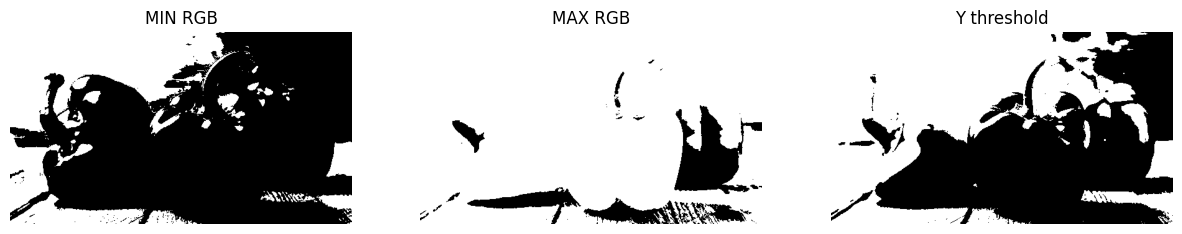

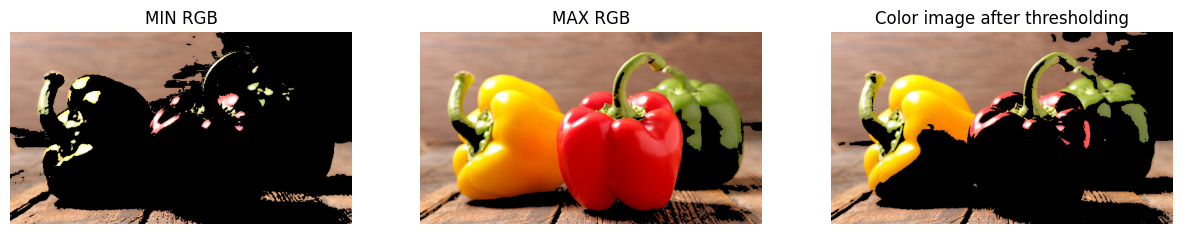

In [100]:
Y_threshold = np.zeros(Y.shape, dtype=np.uint8) 

for i in range(Y.shape[0]):
    for j in range(Y.shape[1]):

        if Y[i,j] > threshold:
            Y_threshold[i,j] = 255
        else:
            Y_threshold[i,j] = 0


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("MIN RGB")
plt.imshow(m, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("MAX RGB")
plt.imshow(M, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Y threshold")
plt.imshow(Y_threshold, cmap='gray')
plt.axis('off')

plt.show()

color_result = im2.copy() 
min_color_result = im2.copy() 
max_color_result = im2.copy() 

for i in range(im2.shape[0]):
    for j in range(im2.shape[1]):

        if Y_threshold[i,j] == 0:
            color_result[i,j] = [0, 0, 0]

for i in range(im2.shape[0]):
    for j in range(im2.shape[1]):

        if M[i,j] == 0:
            max_color_result[i,j] = [0, 0, 0]

for i in range(im2.shape[0]):
    for j in range(im2.shape[1]):

        if m[i,j] == 0:
            min_color_result[i,j] = [0, 0, 0]


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("MIN RGB")
plt.imshow(min_color_result)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("MAX RGB")
plt.imshow(max_color_result)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Color image after thresholding")
plt.imshow(color_result)
plt.axis('off')
plt.show()



# 10)Color space conversion: Consult the documentation
https://docs.opencv.org/3.4/de/d25/imgproc_color_conversions.html
# After converting to YCrCb, display all 3 components.
# Start again with HSV.

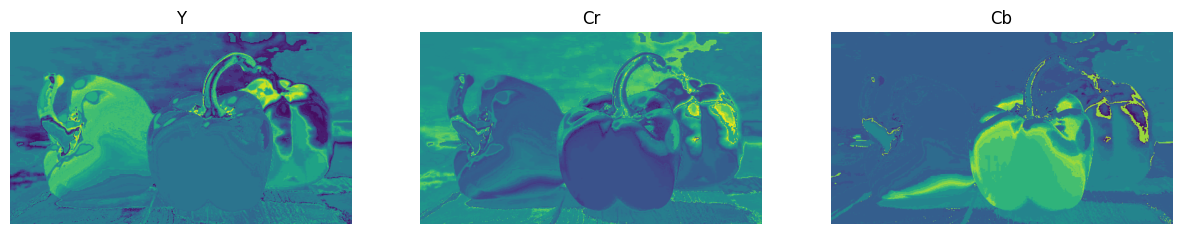

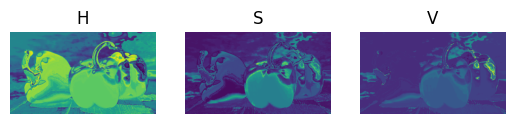

In [118]:

im2 = cv.cvtColor(im2, cv.COLOR_RGB2YCrCb)

Y =im2[:,:,0]
Cr=im2[:,:,1]
Cb=im2[:,:,2]



plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Y")
plt.imshow(Y)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Cr")
plt.imshow(Cr)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Cb")
plt.imshow(Cb)
plt.axis('off')
plt.show()


im2 = cv.cvtColor(im2, cv.COLOR_RGB2HSV)

H =im2[:,:,0]
S=im2[:,:,1]
V=im2[:,:,2]


plt.subplot(1, 3, 1)
plt.title("H")
plt.imshow(H)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("S")
plt.imshow(S)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("V")
plt.imshow(V)
plt.axis('off')
plt.show()



### 11.a)  Display profiles for a line in the top color area of the MireTV.jpg image and a line in the grayscale gamut in the RGB and YCrCb spaces. How is this target designed?

### 11(b)  Propose a method to isolate the red areas and then the green areas in the Parrots and Pens images.

### 11.c)  Propose an algorithm to repaint the "Dedeuche" (2 CV) in green.

Taille de l'image : 1024 x 732
Ligne couleur : 73
Ligne niveaux de gris : 585


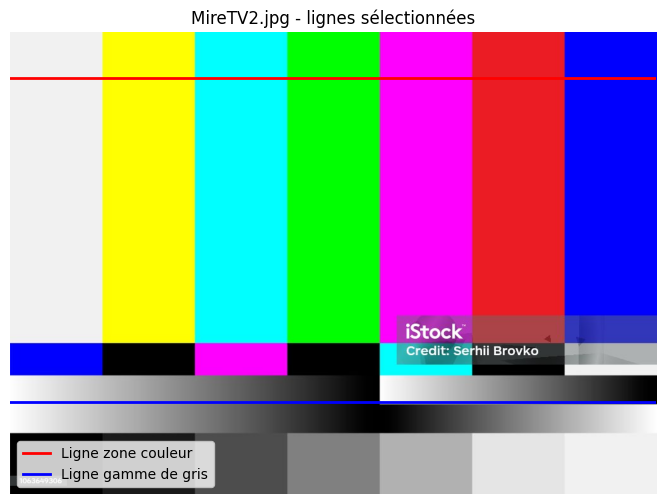

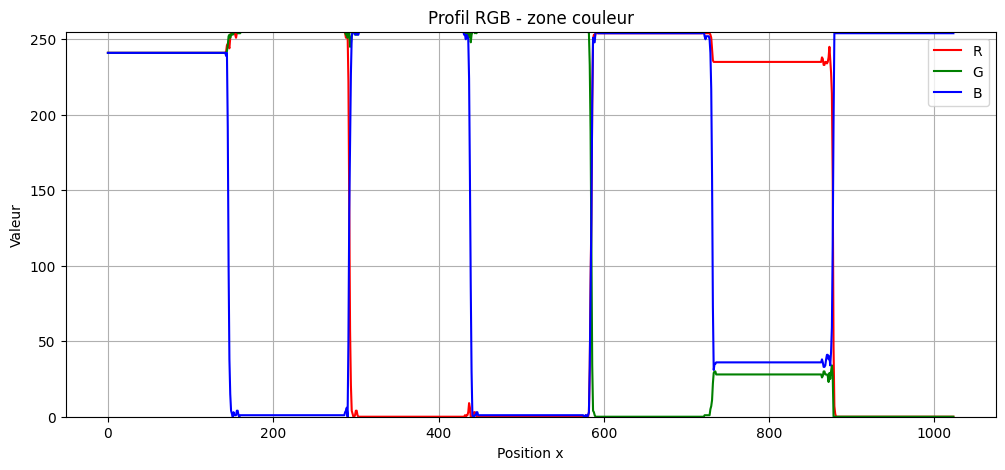

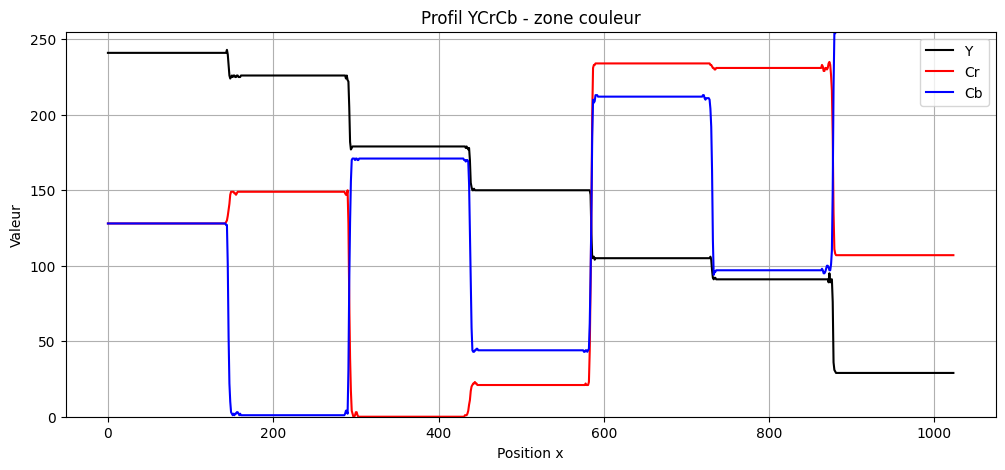

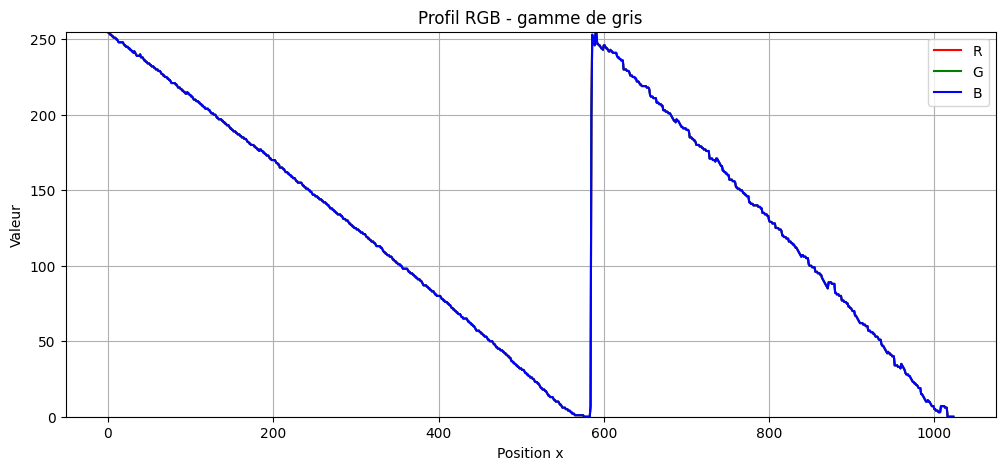

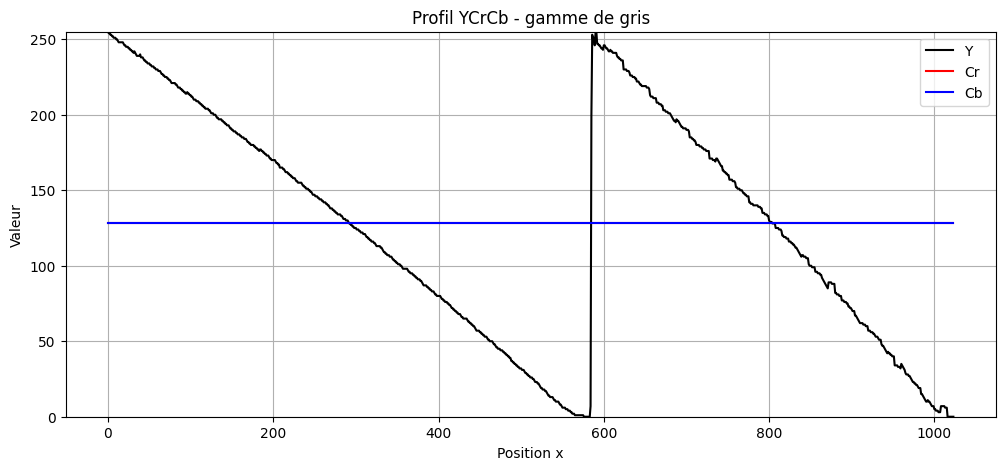

In [ ]:
# 11) 


image = cv.imread("images/MireTV.jpg", cv.IMREAD_COLOR)


# OpenCV lit en BGR -> conversion en RGB
rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB) 

# Conversion RGB -> YCrCb
ycrcb = cv.cvtColor(rgb, cv.COLOR_RGB2YCrCb)

height, width, _ = rgb.shape

print("Taille de l'image :", width, "x", height)


# ============================================================
# 2. Choisir les lignes
# ============================================================

y_color = int(height * 0.10)     # ligne dans la zone colorée supérieure
y_gray = int(height * 0.80)      # ligne dans la gamme de gris

print("Ligne couleur :", y_color)
print("Ligne niveaux de gris :", y_gray)


# ============================================================
# 3. Extraire les profils RGB
# ============================================================

# Profil de la ligne couleur
R_color = rgb[y_color, :, 0]
G_color = rgb[y_color, :, 1]
B_color = rgb[y_color, :, 2]

# Profil de la ligne grayscale
R_gray = rgb[y_gray, :, 0]
G_gray = rgb[y_gray, :, 1]
B_gray = rgb[y_gray, :, 2]


# ============================================================
# 4. Extraire les profils YCrCb
# ============================================================

Y_color = ycrcb[y_color, :, 0]
Cr_color = ycrcb[y_color, :, 1]
Cb_color = ycrcb[y_color, :, 2]

Y_gray = ycrcb[y_gray, :, 0]
Cr_gray = ycrcb[y_gray, :, 1]
Cb_gray = ycrcb[y_gray, :, 2]

x = np.arange(width)


# ============================================================
# 5. Affichage de l'image avec les deux lignes
# ============================================================

plt.figure(figsize=(12, 6))

plt.imshow(rgb)

plt.axhline(y_color, color="red", linewidth=2,label="Ligne zone couleur")

plt.axhline(y_gray, color="blue", linewidth=2,label="Ligne gamme de gris")

plt.title("MireTV2.jpg - lignes sélectionnées")
plt.legend()
plt.axis("off")
plt.show()


# ============================================================
# 6. Profils RGB - zone couleur
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(x, R_color, 'r', label='R')
plt.plot(x, G_color, 'g', label='G')
plt.plot(x, B_color, 'b', label='B')

plt.title("Profil RGB - zone couleur")
plt.xlabel("Position x")
plt.ylabel("Valeur")
plt.ylim(0, 255)
plt.grid()
plt.legend()
plt.show()


# ============================================================
# 7. Profils YCrCb - zone couleur
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(x, Y_color, 'k', label='Y')
plt.plot(x, Cr_color, 'r', label='Cr')
plt.plot(x, Cb_color, 'b', label='Cb')

plt.title("Profil YCrCb - zone couleur")
plt.xlabel("Position x")
plt.ylabel("Valeur")
plt.ylim(0, 255)
plt.grid()
plt.legend()
plt.show()


# ============================================================
# 8. Profils RGB - gamme de gris
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(x, R_gray, 'r', label='R')
plt.plot(x, G_gray, 'g', label='G')
plt.plot(x, B_gray, 'b', label='B')

plt.title("Profil RGB - gamme de gris")
plt.xlabel("Position x")
plt.ylabel("Valeur")
plt.ylim(0, 255)
plt.grid()
plt.legend()
plt.show()


# ============================================================
# 9. Profils YCrCb - gamme de gris
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(x, Y_gray, 'k', label='Y')
plt.plot(x, Cr_gray, 'r', label='Cr')
plt.plot(x, Cb_gray, 'b', label='Cb')

plt.title("Profil YCrCb - gamme de gris")
plt.xlabel("Position x")
plt.ylabel("Valeur")
plt.ylim(0, 255)
plt.grid()
plt.legend()
plt.show()


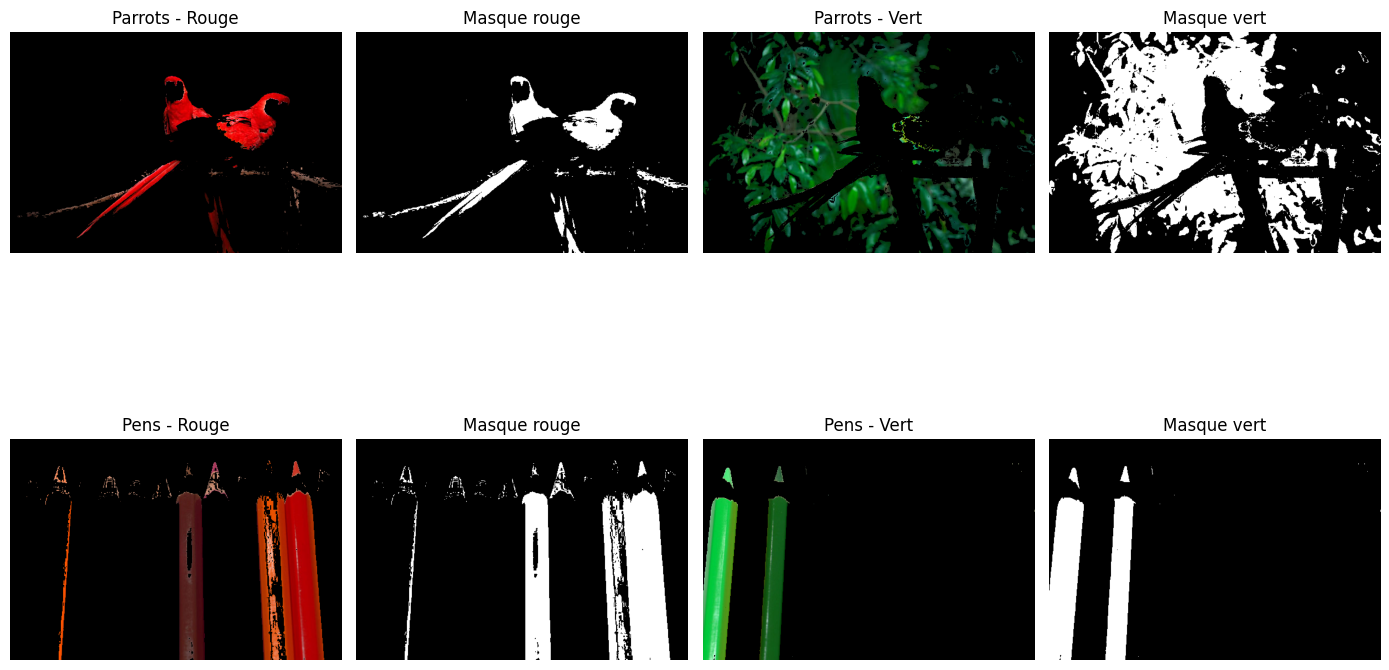

In [140]:

# ============================================================
# Fonction pour isoler une couleur
# ============================================================

def isolate_color(image, color):
    
    # Conversion BGR -> HSV
    hsv = cv.cvtColor(image, cv.COLOR_BGR2HSV)

    if color == "red":
        # Le rouge est présent aux deux extrémités de Hue
        lower_red1 = np.array([0, 80, 50])
        upper_red1 = np.array([10, 255, 255])

        lower_red2 = np.array([170, 80, 50])
        upper_red2 = np.array([179, 255, 255])

        mask1 = cv.inRange(hsv, lower_red1, upper_red1)
        mask2 = cv.inRange(hsv, lower_red2, upper_red2)

        mask = mask1 | mask2

    elif color == "green":
        lower_green = np.array([35, 50, 50])
        upper_green = np.array([85, 255, 255])

        mask = cv.inRange(hsv, lower_green, upper_green)

    # Appliquer le masque à l'image
    result = cv.bitwise_and(image, image, mask=mask)

    return mask, result


# ============================================================
# Charger les images
# ============================================================

parrots = cv.imread("Images/Parrots.jpg")
pens = cv.imread("Images/Pens.jpg")

if parrots is None:
    print("Erreur : Parrots.jpg introuvable")

if pens is None:
    print("Erreur : Pens.jpg introuvable")


# ============================================================
# Isoler le rouge
# ============================================================

mask_parrots_red, parrots_red = isolate_color(parrots, "red")
mask_pens_red, pens_red = isolate_color(pens, "red")


# ============================================================
# Isoler le vert
# ============================================================

mask_parrots_green, parrots_green = isolate_color(parrots, "green")
mask_pens_green, pens_green = isolate_color(pens, "green")


# ============================================================
# Affichage
# ============================================================

plt.figure(figsize=(14, 10))

# Parrots - rouge
plt.subplot(2, 4, 1)
plt.imshow(cv.cvtColor(parrots_red, cv.COLOR_BGR2RGB))
plt.title("Parrots - Rouge")
plt.axis("off")

# Parrots - masque rouge
plt.subplot(2, 4, 2)
plt.imshow(mask_parrots_red, cmap="gray")
plt.title("Masque rouge")
plt.axis("off")

# Parrots - vert
plt.subplot(2, 4, 3)
plt.imshow(cv.cvtColor(parrots_green, cv.COLOR_BGR2RGB))
plt.title("Parrots - Vert")
plt.axis("off")

# Parrots - masque vert
plt.subplot(2, 4, 4)
plt.imshow(mask_parrots_green, cmap="gray")
plt.title("Masque vert")
plt.axis("off")

# Pens - rouge
plt.subplot(2, 4, 5)
plt.imshow(cv.cvtColor(pens_red, cv.COLOR_BGR2RGB))
plt.title("Pens - Rouge")
plt.axis("off")

# Pens - masque rouge
plt.subplot(2, 4, 6)
plt.imshow(mask_pens_red, cmap="gray")
plt.title("Masque rouge")
plt.axis("off")

# Pens - vert
plt.subplot(2, 4, 7)
plt.imshow(cv.cvtColor(pens_green, cv.COLOR_BGR2RGB))
plt.title("Pens - Vert")
plt.axis("off")

# Pens - masque vert
plt.subplot(2, 4, 8)
plt.imshow(mask_pens_green, cmap="gray")
plt.title("Masque vert")
plt.axis("off")

plt.tight_layout()
plt.show()


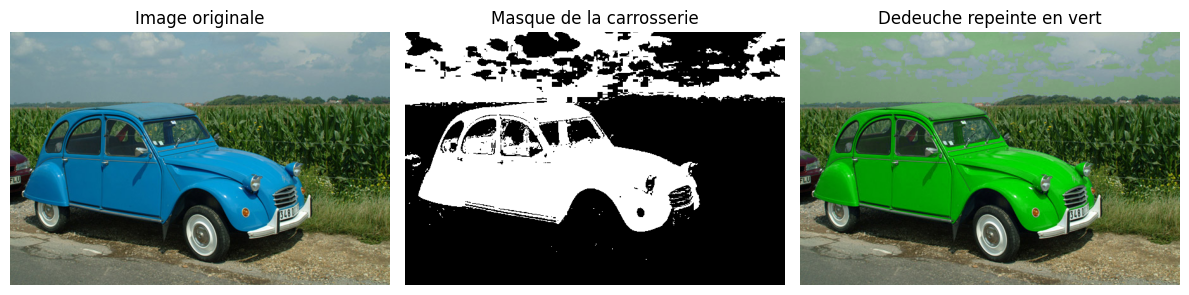

In [145]:


# ============================================================
# 1. Charger l'image
# ============================================================

image = cv.imread("Images/Car.jpg")

if image is None:
    raise FileNotFoundError("Car.jpg introuvable")

# Conversion BGR -> HSV
hsv = cv.cvtColor(image, cv.COLOR_BGR2HSV)


# ============================================================
# 2. Définir la couleur de la carrosserie
# ============================================================

# Exemple pour une carrosserie bleue
lower_blue = np.array([90, 50, 40])
upper_blue = np.array([140, 255, 255])

mask = cv.inRange(hsv, lower_blue, upper_blue)


# ============================================================
# 3. Recolorer en vert
# ============================================================

# Teinte verte dans OpenCV : environ 60
GREEN_HUE = 60

hsv_green = hsv.copy()

# Modifier uniquement H pour les pixels du masque
hsv_green[:, :, 0][mask > 0] = GREEN_HUE


# ============================================================
# 4. Reconvertir en RGB
# ============================================================

result = cv.cvtColor(hsv_green, cv.COLOR_HSV2RGB)
original = cv.cvtColor(image, cv.COLOR_BGR2RGB)


# ============================================================
# 5. Affichage
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Image originale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Masque de la carrosserie")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(result)
plt.title("Dedeuche repeinte en vert")
plt.axis("off")

plt.tight_layout()
plt.show()


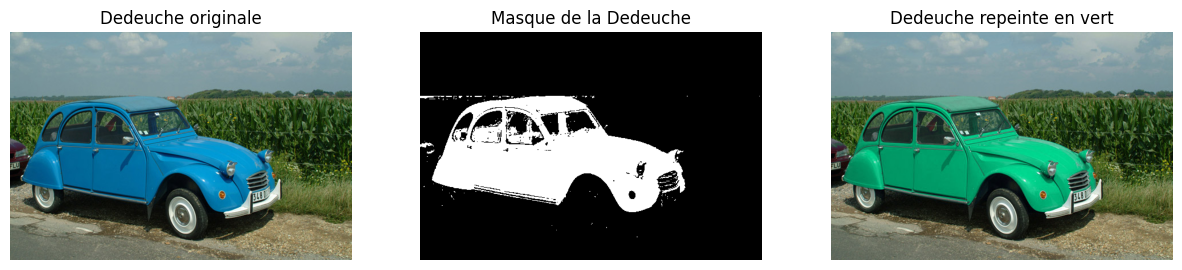

In [165]:


# Charger l'image
image = cv.imread("Images/Car.jpg")

if image is None:
    raise FileNotFoundError("Car.jpg introuvable")

# BGR -> HSV
hsv = cv.cvtColor(image, cv.COLOR_BGR2HSV)

# ------------------------------------------------------------
# 1. Détecter le bleu
# ------------------------------------------------------------

lower_blue = np.array([90, 50, 40])
upper_blue = np.array([140, 255, 255])

blue_mask = cv.inRange(hsv, lower_blue, upper_blue)

# ------------------------------------------------------------
# 2. Limiter la détection à la zone de la voiture
# ------------------------------------------------------------

height, width = image.shape[:2]

# Exemple : on ne garde que la partie basse de l'image
position_mask = np.zeros((height, width), dtype=np.uint8)

position_mask[int(height * 0.28):height, :] = 255

# Combiner les deux masques
mask = cv.bitwise_and(blue_mask, position_mask)

# ------------------------------------------------------------
# 3. Transformer le bleu en vert
# ------------------------------------------------------------

hsv_green = hsv.copy()

# Vert = H ≈ 80
hsv_green[:, :, 0][mask > 0] = 80

# HSV -> RGB
result = cv.cvtColor(hsv_green, cv.COLOR_HSV2RGB)

# Image originale
original = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# ------------------------------------------------------------
# 4. Affichage
# ------------------------------------------------------------

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Dedeuche originale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Masque de la Dedeuche")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(result)
plt.title("Dedeuche repeinte en vert")
plt.axis("off")

plt.show()
